<left><img width=25% src="img/gw_monogram_2c.png"></left>

# Lecture 2: Machine Learning Setup

### ECE6210 Machine Intelligence

__Armin Mehrabian__<br>The George Washington Universiry

# Announcements

* Announcement
     * Subannounce


# Recall: Supervised Learning

Consider a chemical sensor array used for concentration estimation.

1. Record sensor responses under known gases and concentrations.
2. Train a model using these labeled measurements.
3. Evaluate the model on measurements that were not used for training.


# Part 1: A Supervised Learning Problem

We begin with a sensor-calibration problem.


# A Recipe for Applying Supervised Learning

To apply supervised learning, we define a dataset and a learning algorithm.

$$ \text{Dataset} + \text{Learning Algorithm} \to \text{Predictive Model} $$

The output is a predictive model that maps inputs to targets. For instance, it can predict targets on new inputs.

# A Supervised Learning Dataset

We use measurements from a chemical sensor array.

* Six gases were measured at different concentrations.
* Sixteen sensors produced 128 steady-state and transient features.
* We first estimate ethanol concentration from one sensor feature.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

try:
    from slides.course_data import load_gas_sensor_drift
except ModuleNotFoundError:
    from course_data import load_gas_sensor_drift

sensor_data = load_gas_sensor_drift(as_frame=True)
sensor_frame = sensor_data.frame
response_feature = "sensor_13_normalized_DR"

ethanol = sensor_frame.loc[sensor_frame["gas"] == "Ethanol"].copy()
ethanol_train = ethanol.loc[ethanol["batch"] <= 8].sample(
    n=120, random_state=21
).sort_values(response_feature)
ethanol_test = ethanol.loc[ethanol["batch"] >= 9].sample(
    n=5, random_state=21
).sort_values(response_feature)

X_train = ethanol_train[[response_feature]]
y_train = ethanol_train["concentration_ppmv"]
pd.concat([X_train, y_train], axis=1).head()


,sensor_13_normalized_DR,concentration_ppmv
674,0.995704,600.0
676,0.998030,600.0
42,1.894721,10.0
4473,1.923714,10.0
4525,1.945026,10.0


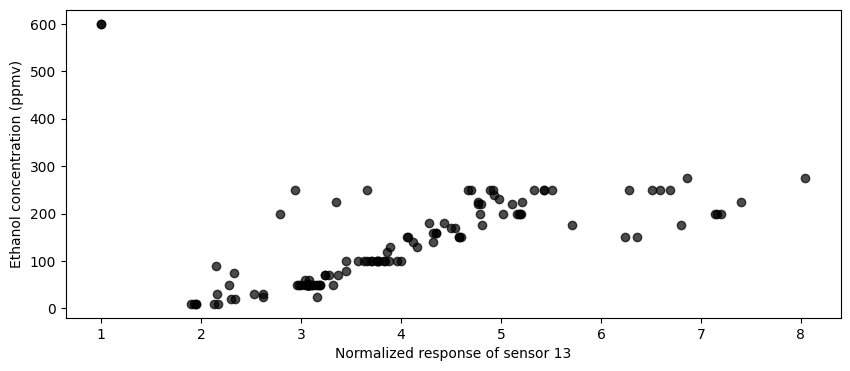

In [2]:
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 4]

plt.scatter(X_train[response_feature], y_train, color="black", alpha=0.7)
plt.xlabel("Normalized response of sensor 13")
plt.ylabel("Ethanol concentration (ppmv)")
plt.show()


# The Model Family

Assume that concentration is a linear function of one sensor response. For unknown parameters $\theta_0, \theta_1 \in \mathbb{R}$,

$$ y = \theta_1 x + \theta_0,$$

where $x$ is the normalized sensor response and $y$ is concentration.

Different values of $\theta_0$ and $\theta_1$ define the model family.


We can visualize this for a few values of $\theta_1, \theta_0$.

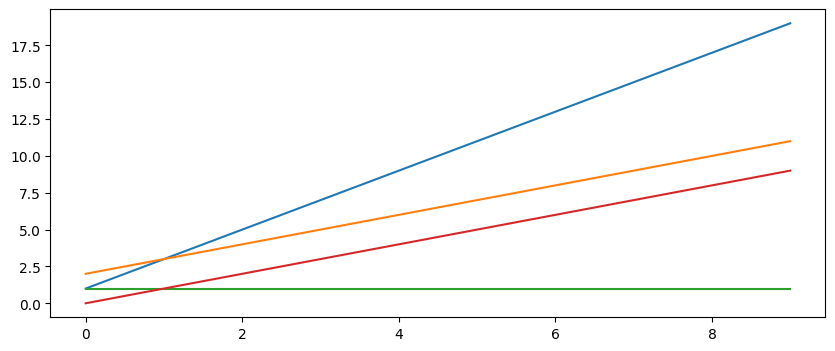

In [3]:
theta_list = [(1, 2), (2,1), (1,0), (0,1)]
for theta0, theta1 in theta_list:
    x = np.arange(10)
    y = theta1 * x + theta0
    plt.plot(x,y)

# A Supervised Learning Algorithm: The Optimizer

Given our assumption that $x,y$ follow the a linear relationship, the goal of a supervised learning algorithm is to find a good set of parameters consistent with the data.

This is an optimization problem.

For now, let's call the `sklearn.linear_model` library to find a $\theta_1, \theta_0$ that fit the data well.

In [4]:
from sklearn.metrics import mean_squared_error

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)
y_train_pred = regr.predict(X_train)

print("Slope (theta1):", round(regr.coef_[0], 2))
print("Intercept (theta0):", round(regr.intercept_, 2))


Slope (theta1): 32.45
Intercept (theta0): 5.86


# A Supervised Learning Model

The learning algorithm returns parameters $\theta_1^*$ and $\theta_0^*$. They define the predictive model

$$ f(x) = \theta_1^* x + \theta_0^*. $$

The model maps a sensor response to an estimated concentration.


We can visualize the linear model that best fits our data.

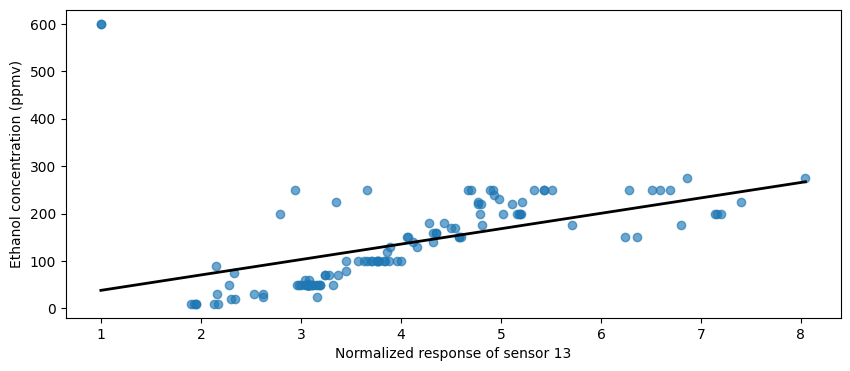

In [5]:
plt.scatter(X_train[response_feature], y_train, alpha=0.65)
plt.plot(X_train[response_feature], y_train_pred, color="black", linewidth=2)
plt.xlabel("Normalized response of sensor 13")
plt.ylabel("Ethanol concentration (ppmv)")
plt.show()


# Making New Predictions

The trained model can estimate concentration for a new sensor measurement.

For a new response $x_{\mathrm{new}}$, the estimate is

$$ y_{\mathrm{new}} = f(x_{\mathrm{new}}) = \theta_1^* x_{\mathrm{new}} + \theta_0^*. $$


The five red points below come from later acquisition batches. They were not used for training.


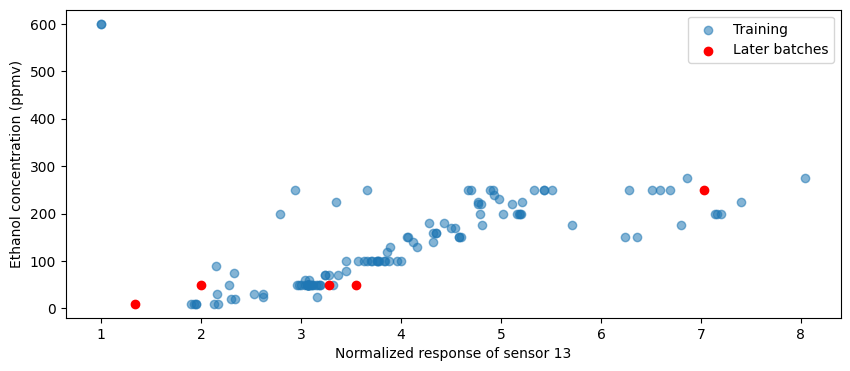

In [6]:
X_test = ethanol_test[[response_feature]]
y_test = ethanol_test["concentration_ppmv"]

plt.scatter(X_train[response_feature], y_train, alpha=0.55, label="Training")
plt.scatter(X_test[response_feature], y_test, color="red", label="Later batches")
plt.xlabel("Normalized response of sensor 13")
plt.ylabel("Ethanol concentration (ppmv)")
plt.legend()
plt.show()


The model provides an estimated concentration for each new response.


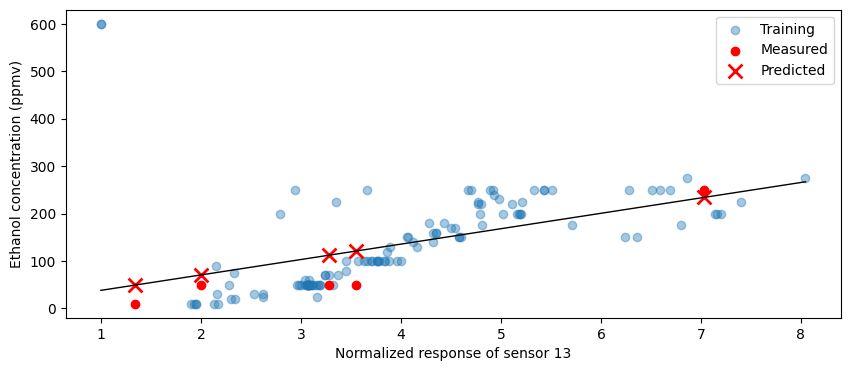

In [7]:
y_test_pred = regr.predict(X_test)

plt.scatter(X_train[response_feature], y_train, alpha=0.4, label="Training")
plt.scatter(X_test[response_feature], y_test, color="red", label="Measured")
plt.scatter(
    X_test[response_feature], y_test_pred,
    color="red", marker="x", s=100, linewidth=2, label="Predicted"
)
plt.plot(X_train[response_feature], y_train_pred, color="black", linewidth=1)
plt.xlabel("Normalized response of sensor 13")
plt.ylabel("Ethanol concentration (ppmv)")
plt.legend()
plt.show()


# Why Supervised Learning?

Supervised learning can be useful in many ways.
* Making predictions on new data.
* Understanding the mechanisms through which input variables affect targets.

# Current Applications

Supervised learning is used for several measurement and decision problems.

* Estimate battery state of charge from voltage, current, and temperature.
* Forecast electric load and renewable generation.
* Detect faults from vibration or waveform measurements.
* Identify objects and free space for robotic systems.
* Predict molecular interactions and material properties.


<left><img width=25% src="img/gw_monogram_2c.png"></left>
# Part 2: Anatomy of a Supervised Learning Problem: The Dataset

We have seen an example of supervised machine learning.

Let's now examine more closely the components of a supervised learning problem, starting with the dataset.

# Recall: Three Components of a Supervised Machine Learning Problem

To apply supervised learning, we define a dataset and a learning algorithm.

$$ \text{Dataset} + \text{Learning Algorithm} \to \text{Predictive Model} $$

The output is a predictive model that maps inputs to targets. For instance, it can predict targets on new inputs.

# A Supervised Learning Dataset

We continue with the gas-sensor dataset. It provides continuous targets for regression and categorical targets for classification.


Each measurement contains 128 features. They summarize the responses of 16 chemical sensors. The dataset also records gas identity, concentration, and acquisition batch.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from slides.course_data import load_gas_sensor_drift
except ModuleNotFoundError:
    from course_data import load_gas_sensor_drift

sensor_data = load_gas_sensor_drift(as_frame=True)
sensor_frame = sensor_data.frame

print(sensor_data.DESCR)
print("Measurements:", sensor_data.data.shape[0])
print("Features:", sensor_data.data.shape[1])
print("Gases:", ", ".join(sensor_data.target_names))


Measurements from 16 chemical sensors exposed to six gases at different concentrations. The 128 features summarize steady-state and transient sensor responses.
Measurements: 13910
Features: 128
Gases: Ethanol, Ethylene, Ammonia, Acetaldehyde, Acetone, Toluene


# A Supervised Learning Dataset: Notation

A training dataset of size $n$ is

$$\mathcal{D} = \{(x^{(i)}, y^{(i)}) \mid i = 1,2,\ldots,n\}.$$

Each $x^{(i)}$ contains the sensor features for measurement $i$. The target $y^{(i)}$ may be gas concentration or gas identity.

Together, $(x^{(i)}, y^{(i)})$ form one training example.


The first rows below show sensor features and the concentration target.


In [9]:
sensor_X = sensor_data.data.copy()
sensor_y = sensor_data.concentration.copy()

pd.concat(
    [sensor_X.iloc[:, :6], sensor_y.rename("concentration_ppmv")], axis=1
).head()


,sensor_01_DR,sensor_01_normalized_DR,sensor_01_rise_EMA_0.001,sensor_01_rise_EMA_0.01,sensor_01_rise_EMA_0.1,sensor_01_decay_EMA_0.001,concentration_ppmv
0,15596.162109,1.868245,2.371604,2.803678,7.512213,-2.739388,10.0
1,26402.070312,2.532401,5.411209,6.509906,7.658469,-4.722217,20.0
2,42103.582031,3.454189,8.198175,10.508439,11.611003,-7.668313,30.0
3,42825.988281,3.451192,12.113940,16.266853,39.910057,-7.849409,40.0
4,58151.175781,4.194839,11.455096,15.715298,17.654915,-11.083364,50.0


# Training Dataset: Inputs

An input $x^{(i)} \in \mathcal{X}$ is a $d$-dimensional vector

$$ x^{(i)} = [x^{(i)}_1, x^{(i)}_2, \ldots, x^{(i)}_d]^\top. $$

In this dataset, one input contains 128 steady-state and transient response features. The feature space is $\mathcal{X}=\mathbb{R}^{128}$.


The values below describe one sensor-array measurement.


In [10]:
sensor_X.iloc[0, :8]


sensor_01_DR                 15596.162109
sensor_01_normalized_DR          1.868245
sensor_01_rise_EMA_0.001         2.371604
sensor_01_rise_EMA_0.01          2.803678
sensor_01_rise_EMA_0.1           7.512213
sensor_01_decay_EMA_0.001       -2.739388
sensor_01_decay_EMA_0.01        -3.344671
sensor_01_decay_EMA_0.1         -4.847512
Name: 0, dtype: float32

# Training Dataset: Attributes

The measured and recorded attributes include:

* Resistance changes from 16 sensors
* Summaries of rising and decaying transients
* Gas identity and concentration
* Acquisition batch

The batch identifies when a measurement was collected. It is important when sensor drift is evaluated.


# Training Dataset: Features

Features are numerical descriptions used by a model. The dataset includes steady-state resistance changes and exponential-moving-average summaries of sensor transients.

We may also construct new features. A logarithmic magnitude can reduce the effect of a large numerical range.


We create a logarithmic version of one steady-state response.


In [11]:
sensor_X["sensor_01_log_abs_DR"] = np.log1p(
    np.abs(sensor_X["sensor_01_DR"])
)
sensor_X[["sensor_01_DR", "sensor_01_log_abs_DR"]].head()


,sensor_01_DR,sensor_01_log_abs_DR
0,15596.162109,9.654844
1,26402.070312,10.181235
2,42103.582031,10.647912
3,42825.988281,10.664924
4,58151.175781,10.970819


# Training Dataset: Features

We may denote features via a function $\phi : \mathcal{X} \to \mathbb{R}^p$ that takes an input $x^{(i)} \in \mathcal{X}$ and outputs a $p$-dimensional vector
$$ \phi(x^{(i)}) = \left[\begin{array}{@{}c@{}}
\phi(x^{(i)})_1 \\
\phi(x^{(i)})_2 \\
\vdots \\
\phi(x^{(i)})_p
\end{array} \right]$$
We say that $\phi(x^{(i)})$ is a *featurized* input, and each $\phi(x^{(i)})_j$ is a *feature*.

# Features vs Attributes

In practice, the terms attribute and features are often used interchangeably. Most authors refer to $x^{(i)}$ as a vector of features. 

We will follow this convention and use the term "attribute" only when there is ambiguity between features and attributes.

# Features: Discrete vs. Continuous 

Features can be either discrete or continuous. We will see that some ML algorthims handle these differently.

The normalized response of sensor 13 is a continuous feature. Its values lie on a numerical interval.


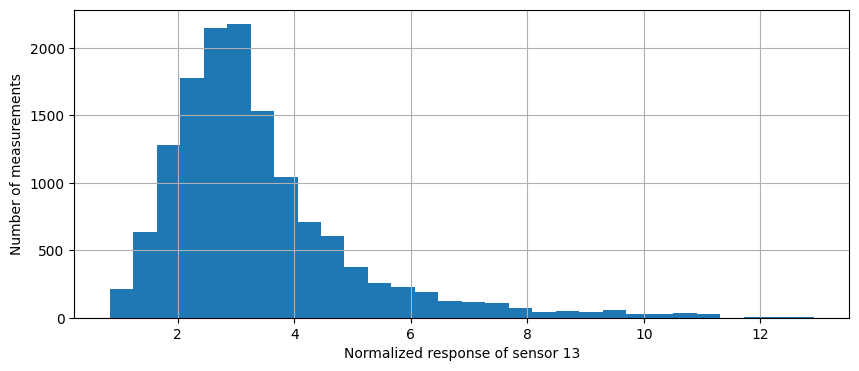

In [12]:
sensor_X["sensor_13_normalized_DR"].hist(bins=30)
plt.xlabel("Normalized response of sensor 13")
plt.ylabel("Number of measurements")
plt.show()


Acquisition batch is a discrete variable. It takes one of ten integer values. Batch order also contains temporal information.


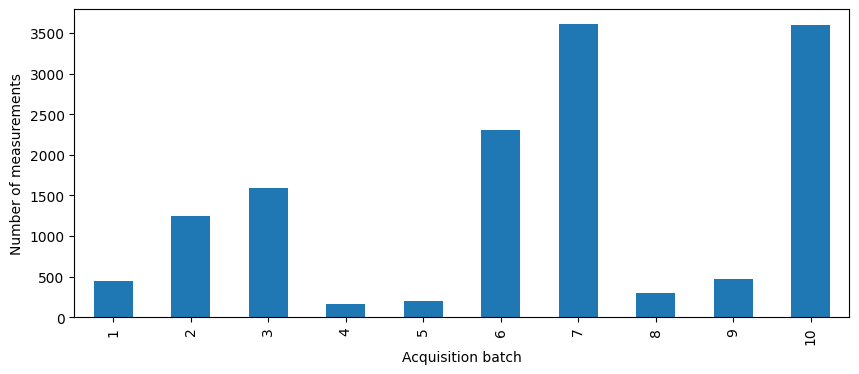

In [13]:
sensor_frame["batch"].value_counts().sort_index().plot.bar()
plt.xlabel("Acquisition batch")
plt.ylabel("Number of measurements")
plt.show()


# Training Dataset: Targets

The target is the quantity that the model should predict.

* Concentration is a continuous target for regression.
* Gas identity is a categorical target for classification.

The same measurements can therefore support different learning problems.


The distribution of measured concentrations is shown below.


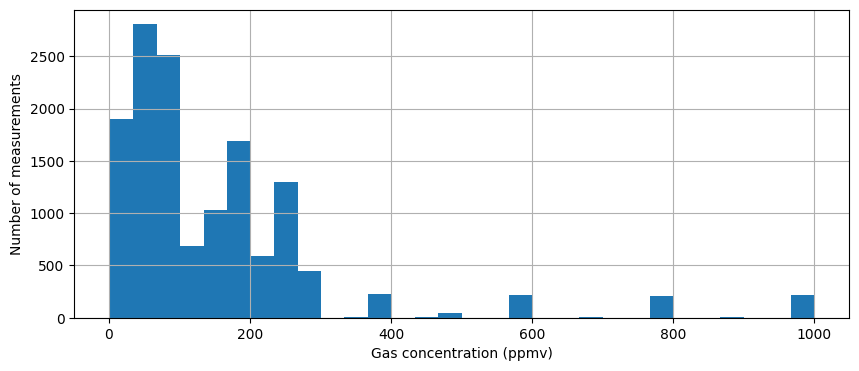

In [14]:
sensor_y.hist(bins=30)
plt.xlabel("Gas concentration (ppmv)")
plt.ylabel("Number of measurements")
plt.show()


# Targets: Regression vs. Classification

We distinguish between two broad types of supervised learning problems that differ in the form of the target variable.

1. __Regression__: The target variable $y$ is continuous. We are fitting a curve in a high-dimensional feature space that approximates the shape of the dataset.
2. __Classification__: The target variable $y$ is discrete. Each discrete value corresponds to a *class* and we are looking for a hyperplane that separates the different classes.

The gas-identity target can also define a binary task. For example, a detector may distinguish ammonia from all other gases.


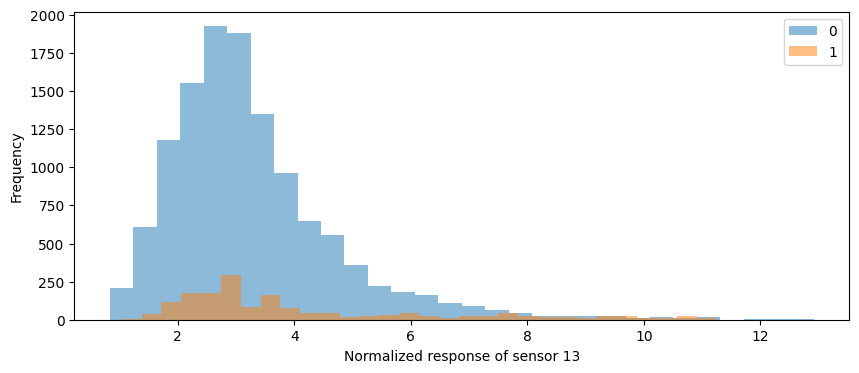

In [15]:
ammonia_target = (sensor_frame["gas"] == "Ammonia").astype(int)
sensor_frame.groupby(ammonia_target)[response_feature].plot.hist(
    bins=30, alpha=0.5, legend=True
)
plt.xlabel("Normalized response of sensor 13")
plt.show()


A logistic classifier can estimate whether a measurement corresponds to ammonia.


In [16]:
clf = linear_model.LogisticRegression(max_iter=1000)
clf.fit(sensor_frame[[response_feature]], ammonia_target)
print("Training accuracy:", round(clf.score(sensor_frame[[response_feature]], ammonia_target), 3))


Training accuracy: 0.881


<left><img width=25% src="img/gw_monogram_2c.png"></left>
# Part 3: Anatomy of a Supervised Learning Problem: The Learning Algorithm

Let's now look at what a general supervised learning algorithm looks like.

# Recall: Three Components of a Supervised Machine Learning Problem

To apply supervised learning, we define a dataset and a learning algorithm.

$$ \text{Dataset} + \text{Learning Algorithm} \to \text{Predictive Model} $$

The output is a predictive model that maps inputs to targets. For instance, it can predict targets on new inputs.

# The Components of a Supervised Machine Learning Algorithm

We can also define the high-level structure of a supervised learning algorithm as consisting of three components:
* A __model class__: the set of possible models we consider.
* An __objective__ function, which defines how good a model is.
* An __optimizer__, which finds the best predictive model in the model class according to the objective function

We use the sensor-calibration problem to connect the model class, objective, and optimizer.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

try:
    from slides.course_data import load_gas_sensor_drift
except ModuleNotFoundError:
    from course_data import load_gas_sensor_drift

sensor_data = load_gas_sensor_drift(as_frame=True)
sensor_frame = sensor_data.frame
response_feature = "sensor_13_normalized_DR"
sensor_frame[[response_feature, "gas", "concentration_ppmv", "batch"]].head()


,sensor_13_normalized_DR,gas,concentration_ppmv,batch
0,1.779291,Ethanol,10.0,1
1,2.067927,Ethanol,20.0,1
2,2.466508,Ethanol,30.0,1
3,2.560248,Ethanol,40.0,1
4,3.067174,Ethanol,50.0,1


# Model: Notation

We'll say that a model is a function
$$ f : \mathcal{X} \to \mathcal{Y} $$
that maps inputs $x \in \mathcal{X}$ to targets $y \in \mathcal{Y}$.

Often, models have *parameters* $\theta \in \Theta$ living in a set $\Theta$. We will then write the model as
$$ f_\theta : \mathcal{X} \to \mathcal{Y} $$
to denote that it's parametrized by $\theta$.

### <span style="color:red; font-weight:bold;">NOTE:</span>
In Machine Learning terminology the model $f$ is also represented as $h$ interchangeably, which stands for **"hypothesis"** 

# Model Class: Notation

Formally, the model class is a set 
$$\mathcal{M} \subseteq \{f \mid f : \mathcal{X} \to \mathcal{Y} \}$$
of possible models that map input features to targets.

When the models $f_\theta$ are paremetrized by *parameters* $\theta \in \Theta$ living in some set $\Theta$. Thus we can also write
$$\mathcal{M} = \{f_\theta \mid \theta \in \Theta \}.$$

# Model Class: Example

One simple approach is to assume that $x$ and $y$ are related by a linear model of the form
\begin{align*}
y & = \theta_0 + \theta_1 \cdot x_1 + \theta_2 \cdot x_2 + ... + \theta_d \cdot x_d
\end{align*}
where $x$ is a featurized input and $y$ is the target.

The $\theta_j$ are the *parameters* of the model, $\Theta = \mathbb{R}^{d+1}$, and $\mathcal{M} = \{ \theta_0 + \theta_1 \cdot x_1 + \theta_2 \cdot x_2 + ... + \theta_d \cdot x_d \mid \theta \in \mathbb{R}^{d+1} \}$
<!-- By using the notation $x_0 = 1$, we can represent the model in a vectorized form
$$ y = \sum_{j=0}^d \beta_j \cdot x_j = \vec \beta \cdot \vec x. $$
where $\vec x$ is a vector of features. -->

# Objectives: Notation

<!-- Given a training set, how do we pick the parameters $\theta$ for the model? A natural approach is to select $\theta$ such that $f_\theta(x^{(i)})$ is close to $y^{(i)}$ on a training dataset $\mathcal{D} = \{(x^{(i)}, y^{(i)}) \mid i = 1,2,...,n\}$. -->

To capture this intuition, we define an *objective function* (also called a *loss function*)
$$J(f) : \mathcal{M} \to [0, \infty), $$
which describes the extent to which $f$ "fits" the data $\mathcal{D} = \{(x^{(i)}, y^{(i)}) \mid i = 1,2,...,n\}$.

When $f$ is parametrized by $\theta \in \Theta$, the objective becomes a function $J(\theta) : \Theta \to [0, \infty).$

# Objective: Examples

What would are some possible objective functions? We will see many, but here are a few examples:
* Mean squared error: $$J(\theta) = \frac{1}{2n} \sum_{i=1}^n \left( f_\theta(x^{(i)}) - y^{(i)} \right)^2$$
* Absolute (L1) error: $$J(\theta) = \frac{1}{n} \sum_{i=1}^n \left| f_\theta(x^{(i)}) - y^{(i)} \right|$$

These are defined for a dataset $\mathcal{D} = \{(x^{(i)}, y^{(i)}) \mid i = 1,2,...,n\}$.

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y1 = np.array([1, 2, 3, 4])
y2 = np.array([-1, 1, 3, 5])

print('Mean squared error: %.2f' % mean_squared_error(y1, y2))
print('Mean absolute error: %.2f' % mean_absolute_error(y1, y2))

Mean squared error: 1.50
Mean absolute error: 1.00


# Optimizer: Notation

At a high-level an optimizer takes an objective $J$ and a model class $\mathcal{M}$ and finds a model $f \in \mathcal{M}$ with the smallest value of the objective $J$.

\begin{align*}
\min_{f \in \mathcal{M}} J(f)
\end{align*}

Intuitively, this is the function that bests "fits" the data on the training dataset.

When $f$ is parametrized by $\theta \in \Theta$, the optimizer minimizes a function $J(\theta)$ over all $\theta \in \Theta$.

# Optimizer: Example

We will see that behind the scenes, the `sklearn.linear_models.LinearRegression` algorithm optimizes the MSE loss.

\begin{align*}
\min_{\theta \in \mathbb{R}} \frac{1}{2n} \sum_{i=1}^n \left( f_\theta(x^{(i)}) - y^{(i)} \right)^2
\end{align*}

We can easily measure the quality of the fit on the training set and the test set.

We now apply the algorithm to ethanol concentration estimation.


In [19]:
ethanol = sensor_frame.loc[sensor_frame["gas"] == "Ethanol"].copy()
ethanol_train = ethanol.loc[ethanol["batch"] <= 8].sample(n=120, random_state=21)
ethanol_test = ethanol.loc[ethanol["batch"] >= 9].sample(n=20, random_state=21)

X_train = ethanol_train[[response_feature]]
y_train = ethanol_train["concentration_ppmv"]
X_test = ethanol_test[[response_feature]]
y_test = ethanol_test["concentration_ppmv"]

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)
y_train_pred = regr.predict(X_train)
y_test_pred = regr.predict(X_test)


The red marks show predictions for measurements from later acquisition batches.


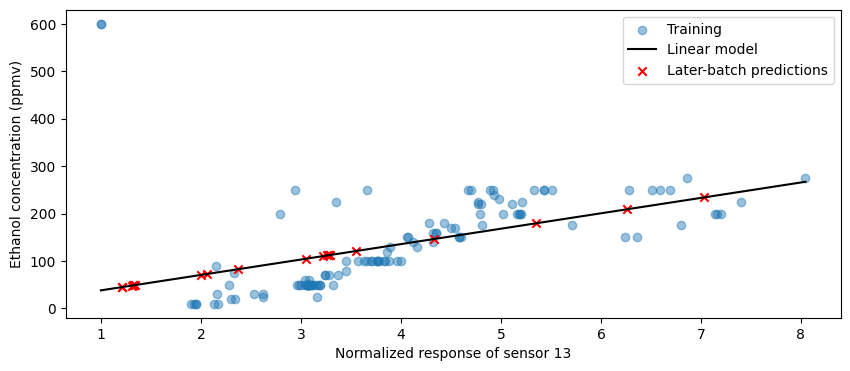

In [20]:
order = np.argsort(X_train[response_feature].to_numpy())
plt.scatter(X_train[response_feature], y_train, alpha=0.45, label="Training")
plt.plot(
    X_train[response_feature].to_numpy()[order], y_train_pred[order],
    color="black", label="Linear model"
)
plt.scatter(X_test[response_feature], y_test_pred, color="red", marker="x", label="Later-batch predictions")
plt.xlabel("Normalized response of sensor 13")
plt.ylabel("Ethanol concentration (ppmv)")
plt.legend()
plt.show()


In [21]:
from sklearn.metrics import mean_squared_error

print("Training RMSE: %.1f ppmv" % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Later-batch RMSE: %.1f ppmv" % np.sqrt(mean_squared_error(y_test, y_test_pred)))


Training RMSE: 88.8 ppmv
Later-batch RMSE: 43.3 ppmv


# Summary: Components of a Supervised Machine Learning Problem

To apply supervised learning, we define a dataset and a learning algorithm.

$$ \underbrace{\text{Dataset}}_\text{Features, Attributes, Targets} + \underbrace{\text{Learning Algorithm}}_\text{Model Class + Objective + Optimizer } \to \text{Predictive Model} $$

The output is a predictive model that maps inputs to targets. For instance, it can predict targets on new inputs.

# Notation: Feature Matrix

For $n$ sensor measurements with $d$ features, the feature matrix is $X \in \mathbb{R}^{n \times d}$. Row $i$ contains the features of measurement $i$.

The target vector $y \in \mathbb{R}^n$ contains one target value for each row. The target may be concentration for regression or gas identity for classification.


# Machine Learning Setup

$\mathcal{D} = \{(x^{(i)}, y^{(i)}) \mid i = 1,2,...,n\} \subseteq \mathbb{R}^{d}\times C$

where:

$\mathbb{R}^{d}:$ $d$-dimensional feature space

$x^{i}:$ 		input vector of the ith sample

$y^{i}:$ 		label of the ith sample

$C$:		label space (Only in Supervised Learning setting)


# Machine Learning Setup

- Unitimately, we want to learn a function $f$ (or $h$)
- Such that for a new pair $(x,y)$~$\mathbb{P}$ (unseen pair by the model during the training)
    - $h(x)=y$ with high probability.
    - In other words $h(x)\approx y$

# Current Supervised Learning Scenarios

| Scenario | Label space | Example |
|---|---|---|
| Binary classification | $\{0,1\}$ | Detect a power-system fault |
| Multiclass classification | $\{1,2,\ldots,K\}$ | Identify a gas or operating state |
| Multilabel classification | $\{0,1\}^K$ | Assign several tags to an image or signal |
| Regression | A continuous interval | Estimate concentration or battery state of charge |


# Machine Learning Process
1. First pick a *hypothesis* class $\mathcal{H}$ (or *model* class $\mathcal{M}$) from all available classes. For instance:
    - Linear Regression
    - or Decision Trees
2. Find (train) the best function $h \in \mathcal{H}$. This is the *"Learning"* process.

Essentially learning is try to find the function $h$ from all possible functions within the Hypothesis class $\mathcal{H}$ that,
- That makes the fewest mistakes within out Training data
- By assessing mistake using a ***Loss function***

# Bad Example of Learning $h$
- Randomly select $h$ from $\mathcal{H}$ and use for prediction.
- Test all functions $h$ in $\mathcal{H}$ and use the best performing for prediction.

# Loss Functions

For a given $h \in \mathcal{H}$:
- A ***Loss function*** evaluates a hypothesis $h$
    - On our training data and tells us how good or bad our trained model $h$ is
    - The higher the loss the worse the perforamance of the model is
    - A Loss of **0 zero** indicates perfect prediction
- It is common practive to normalize Loss by the total number of training data $n$
    - Thus, the output can be interpreted as the average Loss per sample
    - Loss will be independent of $n$

# Example Loss Functions: *Zero/One*
$L_{0/1}(h) = \frac{1}{n} \sum_{i=1}^{n} \delta_{h(x_i) \neq y_i}, \delta_{h(x_i) \neq y_i} = 
\begin{cases} 
1 & \text{if } h(x_i) \neq y_i \\ 
0 & \text{otherwise}
\end{cases}
$

- The simplest Loss function
- Counts how many mistakes hypothesis ***$h$*** makes on the training set
    - ***1*** if mis-predicted
    - ***0*** otherwise

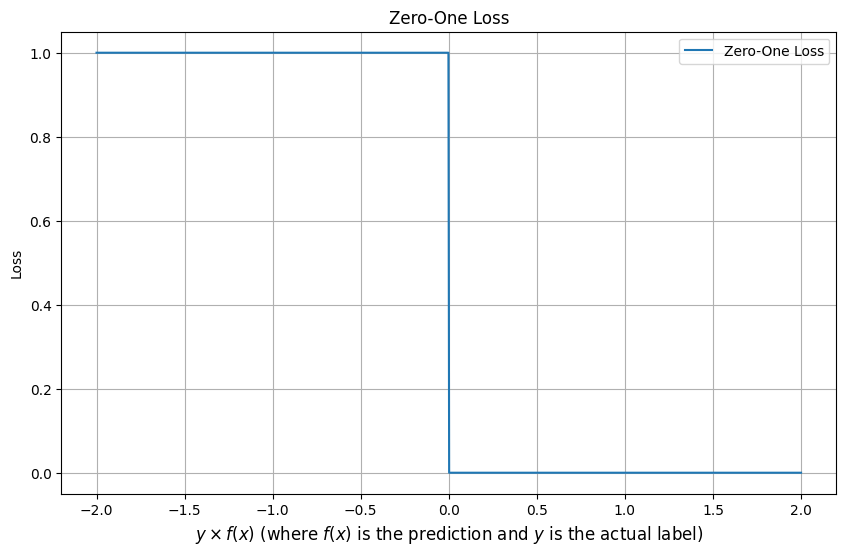

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Values for y * f(x)
y_fx = np.linspace(-2, 2, 1000)

# Zero-one loss function
zero_one_loss = y_fx < 0

# Plot the zero-one loss
plt.figure(figsize=(10, 6))
plt.plot(y_fx, zero_one_loss, label='Zero-One Loss')
plt.xlabel(r'$y \times f(x)$ (where $f(x)$ is the prediction and $y$ is the actual label)', fontsize=12)
plt.ylabel('Loss')
plt.title('Zero-One Loss')
plt.legend()
plt.grid(True)
plt.show()


# Absolute Loss

$L_{absolute}(h) = \frac{1}{n} \sum_{i=1}^{n} |h(x_i) - y_i|$


- Useful in regression problems where you want to minimize the magnitude of the error
- Without concerning too much about its direction

- **PROS:**
    - Less sensitive to outliers than the square loss function, because it does not square the errors.
    - Clear interpretation - the average loss is the *median* of the errors in prediction.

- **CONS:**
    - It is not smooth at the origin, which can make the optimization problem more difficult
    - Doesn't differentiate between under-prediction and over-prediction
    - For some problems, you might want a loss function that penalizes these differently.

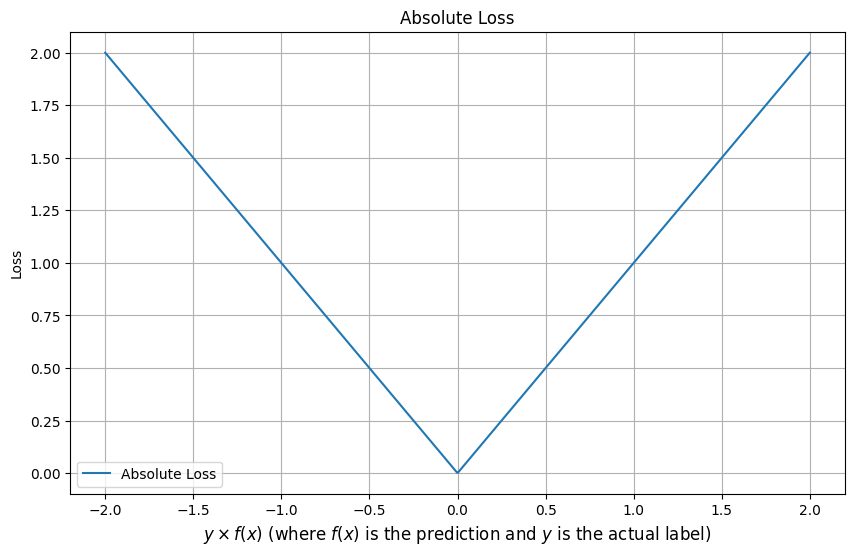

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Values for y - f(x)
y_fx = np.linspace(-2, 2, 1000)

# Absolute loss function
absolute_loss = np.abs(y_fx)

# Plot the absolute loss
plt.figure(figsize=(10, 6))
plt.plot(y_fx, absolute_loss, label='Absolute Loss')
plt.xlabel(r'$y \times f(x)$ (where $f(x)$ is the prediction and $y$ is the actual label)', fontsize=12)
plt.ylabel('Loss')
plt.title('Absolute Loss')
plt.legend()
plt.grid(True)
plt.show()


# Generalization in Machine Learning

- **Definition**: Generalization refers to a model's ability to adapt properly to new, unseen data, drawn from the same distribution as the one used to create the model.

- **Importance**: The ultimate goal of machine learning is to achieve good generalization.
    - It's not enough for a model to learn the training data well (in fact not the goal of ML)
    - It **must** perform well on new unseen data.

# Generalization

For $h \in \mathcal{H},  \forall (x, y) \sim P, \quad h(x) \approx y $

Given a loss function, we can then attempt to find the function $h$ that minimizes the loss:

$ h = argmin_{h \in \mathcal{H}} L(h) $



- We want for,

$h \in \mathcal{H}$,  $\forall (x, y) \sim P, \quad h(x) \approx y $


- In other words we want,

$ E[Loss(h(x,y))]_{(x,y)~P} < \epsilon$

- Thus, can we simply minimize the above expection? Why?

 <span style="color:red; font-weight:bold;">NO</span>, because we don't know what $P$ is.

- A big part of machine learning focuses on the question, how to do this minimization efficiently.

- If you find a function $h(⋅)$ with low loss on your data $\mathcal{D}$
- how do you know whether it will still get examples right that are not in $\mathcal{D}$?

# Question: Memorizer
Imagine the following Loss function. What do you think of it's performance?

$$
h(x) = 
\begin{cases} 
y_i & \text{if } \exists (x_i, y_i) \in D, \text{ s.t. } x = x_i \\ 
0 & \text{otherwise}
\end{cases}
$$

# So what do we do?

# Generalization

- We can calculate an estimate
- we usually split $\mathcal{D}$ into three subsets: 
    - $\mathcal{D}_{TR}$ as the training set
    - $\mathcal{D}_{VA}$ as the validation set (in some textbooks this is called **"test"** set)
    - $\mathcal{D}_{TE}$ as the test set (in some textbooks this is called **"holdout"** set)
    
- We choose (train) $h(⋅)$ based on $\mathcal{D}_{TR}$
- Evaluate $h(⋅)$ on $\mathcal{D}_{VA}$ and select the best model
- Report the performance on $\mathcal{D}_{TE}$
